# Hospital Bed Capacity Importance Experiment

This notebook demonstrates the critical importance of hospital bed capacity (Ward and ICU) in managing an infectious disease outbreak. We will simulate a scenario with high transmission and limited resources, and then systematically vary the healthcare capacity to observe the impact on mortality.

**Key Metrics:**
- **Total Deaths**: The overall mortality burden.
- **Untreated Deaths**: Deaths that occurred specifically because patients could not access necessary care (Ward or ICU) due to capacity constraints.
- **Overflow**: Periods where patient demand exceeds available beds.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

# Add parent directory to path to import modules
current_dir = os.getcwd()
# If running in a notebook, the CWD might be the notebook dir or the project root depending on config.
# We'll assume we need to add the parent dir if we are in 'notebooks'
if os.path.basename(current_dir) == 'notebooks':
    sys.path.append(os.path.abspath('..'))
else:
    # If we are in root, just ensure it's in path
    sys.path.append(os.path.abspath('.'))

from simulate_model import simulate_model
from scenarios import (
    SCENARIO_HOSPITAL_STRESS_TEST,
    DEFAULT_CAPACITY_PARAMS
)

# Setup plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

## 1. Experiment Setup

We will use the **Hospital Stress Test** scenario as our baseline. This scenario features a high transmission rate and limited resources, making it ideal for testing capacity constraints.

In [ ]:
base_scenario = SCENARIO_HOSPITAL_STRESS_TEST.copy()
print(f"Base Scenario: {base_scenario['name']}")
print(f"Description: {base_scenario['description']}")
print(f"Base Ward Capacity: {base_scenario['healthcare_system']['ward_capacity']}")
print(f"Base ICU Capacity: {base_scenario['healthcare_system']['icu_capacity']}")

## 2. Capacity Sweep Simulation

We will iterate through a range of capacity multipliers (from 20% to 500% of baseline) to see how the system responds. For each run, we track the total deaths and the breakdown of treated vs. untreated deaths.

In [9]:
# Define capacity multipliers to test
capacity_multipliers = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0, 3.0, 5.0]

results_data = []

print("Running capacity sweep...")
for mult in capacity_multipliers:
    # Create a modified healthcare system config
    hc_system = base_scenario['healthcare_system'].copy()
    hc_system['ward_capacity'] = int(hc_system['ward_capacity'] * mult)
    hc_system['icu_capacity'] = int(hc_system['icu_capacity'] * mult)
    
    # Run simulation
    # Note: We pass the healthcare system parameters via capacity_config
    capacity_config = {
        'ward_capacity': hc_system['ward_capacity'],
        'icu_capacity': hc_system['icu_capacity'],
        'hill_coef_ward': hc_system['hill_coef_ward'],
        'hill_coef_icu': hc_system['hill_coef_icu'],
    }
    
    res = simulate_model(
        beta_base=base_scenario['beta_base'],
        age_params=base_scenario['age_params'],
        contact_matrix=base_scenario['contact_matrix'],
        age_pops=hc_system['age_pops'],
        sim_config={'Tmax': base_scenario['Tmax']},
        capacity_config=capacity_config,
        vaccine_config=base_scenario.get('vaccination', {}),
        seasonal_config=base_scenario.get('seasonal_params'),
        intervention_config=base_scenario.get('interventions'),
        track_differential_mortality=True
    )
    
    # Collect metrics
    total_deaths = res['D_total'][-1]
    treated_deaths = res['D_treated_total'][-1]
    untreated_deaths = res['D_untreated_total'][-1]
    peak_ward_demand = np.max(res['H_ward_total'])
    peak_icu_demand = np.max(res['H_icu_total'])
    
    results_data.append({
        'Multiplier': mult,
        'Ward_Capacity': hc_system['ward_capacity'],
        'ICU_Capacity': hc_system['icu_capacity'],
        'Total_Deaths': total_deaths,
        'Treated_Deaths': treated_deaths,
        'Untreated_Deaths': untreated_deaths,
        'Peak_Ward_Demand': peak_ward_demand,
        'Peak_ICU_Demand': peak_icu_demand,
        'Pct_Untreated_Deaths': (untreated_deaths / total_deaths * 100) if total_deaths > 0 else 0
    })

df_results = pd.DataFrame(results_data)
df_results

Running capacity sweep...


,Multiplier,Ward_Capacity,ICU_Capacity,Total_Deaths,Treated_Deaths,Untreated_Deaths,Peak_Ward_Demand,Peak_ICU_Demand,Pct_Untreated_Deaths
0,0.2,16,4,24929.660677,3281.668402,21647.992275,42.506208,6.075881,86.836289
1,0.4,32,8,24862.731295,3332.660965,21530.070330,73.587186,11.748612,86.595757
2,0.6,48,12,24804.448870,3378.000720,21426.448150,101.377943,17.270364,86.381472
3,0.8,64,16,24751.347981,3419.907582,21331.440399,127.202911,22.693531,86.182944
4,1.0,80,20,24701.900471,3459.370678,21242.529793,151.643302,28.042889,85.995528
5,1.2,96,24,24655.250381,3496.948148,21158.302233,175.024079,33.333150,85.816619
6,1.5,120,30,24589.378422,3550.528171,21038.850252,208.539461,41.177744,85.560724
7,2.0,160,40,24487.907601,3634.132751,20853.774850,261.240040,54.058441,85.159480
8,3.0,240,60,24306.597296,3786.343869,20520.253427,358.389827,79.278888,84.422567
9,5.0,400,100,23997.470181,4053.005491,19944.464689,532.065605,128.236235,83.110697


## 3. Visualization: The Cost of Limited Capacity

The plot below shows how total deaths decrease as capacity increases. The red dashed line represents "Untreated Deaths"—lives lost specifically because the hospital system was overwhelmed. As capacity increases, this number drops to zero.

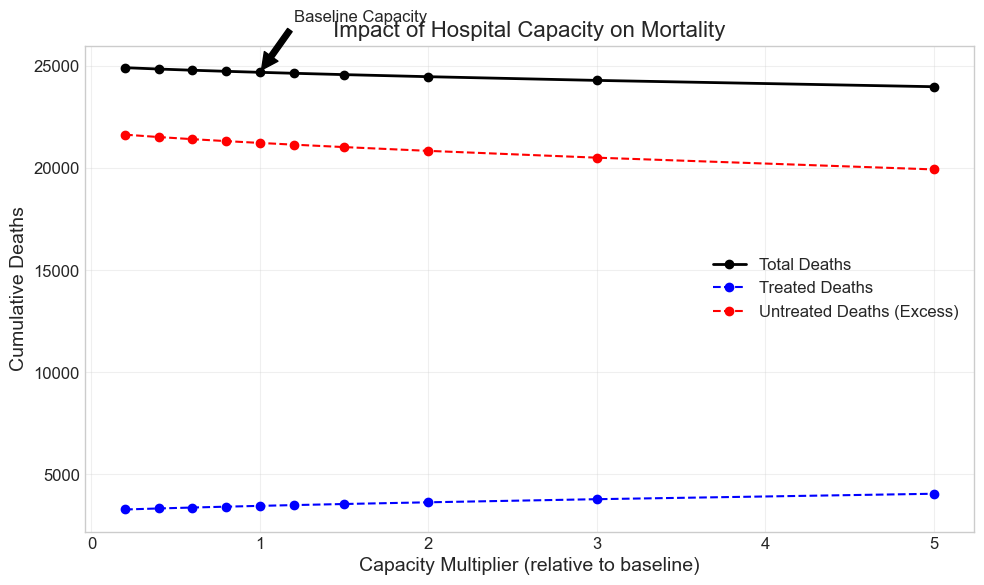

In [8]:
# Plot Mortality vs Capacity Multiplier
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df_results['Multiplier'], df_results['Total_Deaths'], 'o-', label='Total Deaths', color='black', linewidth=2)
ax.plot(df_results['Multiplier'], df_results['Treated_Deaths'], 'o--', label='Treated Deaths', color='blue')
ax.plot(df_results['Multiplier'], df_results['Untreated_Deaths'], 'o--', label='Untreated Deaths (Excess)', color='red')

ax.set_xlabel('Capacity Multiplier (relative to baseline)', fontsize=14)
ax.set_ylabel('Cumulative Deaths', fontsize=14)
ax.set_title('Impact of Hospital Capacity on Mortality', fontsize=16)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Add annotation for the baseline
baseline_deaths = df_results.loc[df_results['Multiplier'] == 1.0, 'Total_Deaths'].values[0]
ax.annotate('Baseline Capacity', xy=(1.0, baseline_deaths), xytext=(1.2, baseline_deaths*1.1),
            arrowprops=dict(facecolor='black', shrink=0.05))

plt.tight_layout()
plt.show()

In [ ]:
# Stacked area plot for Treated vs Untreated
fig, ax = plt.subplots(figsize=(10, 6))

ax.stackplot(df_results['Multiplier'], 
             df_results['Treated_Deaths'], 
             df_results['Untreated_Deaths'],
             labels=['Treated Deaths', 'Untreated (Excess) Deaths'],
             colors=['#3498db', '#e74c3c'], alpha=0.8)

ax.set_xlabel('Capacity Multiplier', fontsize=14)
ax.set_ylabel('Cumulative Deaths', fontsize=14)
ax.set_title('Composition of Mortality by Capacity Level', fontsize=16)
ax.legend(loc='upper right', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Time Series Comparison: Low vs. High Capacity

Here we compare the dynamics of two specific scenarios: one with 50% capacity (Severe Shortage) and one with 200% capacity (Surge Capacity). Notice how the "Low Capacity" scenario hits the ceiling (red dashed line) and stays there, accumulating untreated deaths.

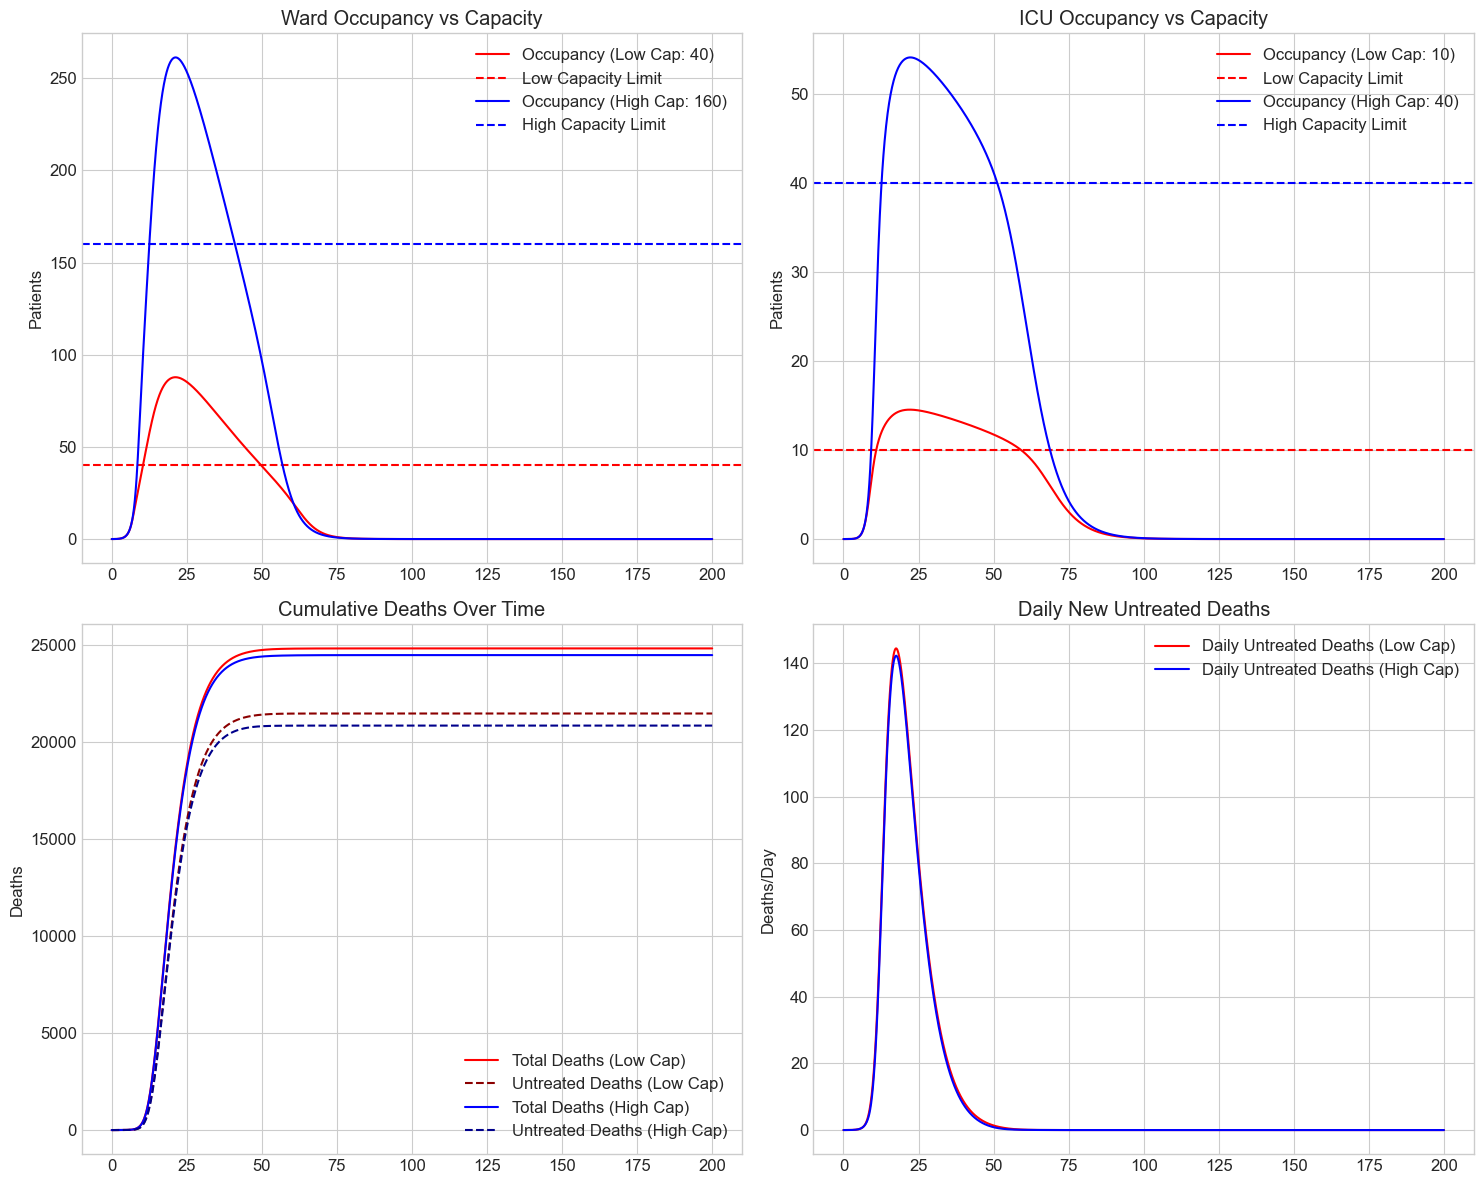

In [7]:
# Compare Low vs High Capacity Dynamics
mult_low = 0.5
mult_high = 2.0

def run_sim(mult):
    hc_system = base_scenario['healthcare_system'].copy()
    hc_system['ward_capacity'] = int(hc_system['ward_capacity'] * mult)
    hc_system['icu_capacity'] = int(hc_system['icu_capacity'] * mult)
    
    capacity_config = {
        'ward_capacity': hc_system['ward_capacity'],
        'icu_capacity': hc_system['icu_capacity'],
        'hill_coef_ward': hc_system['hill_coef_ward'],
        'hill_coef_icu': hc_system['hill_coef_icu'],
    }
    
    return simulate_model(
        beta_base=base_scenario['beta_base'],
        age_params=base_scenario['age_params'],
        contact_matrix=base_scenario['contact_matrix'],
        age_pops=hc_system['age_pops'],
        sim_config={'Tmax': base_scenario['Tmax']},
        capacity_config=capacity_config,
        vaccine_config=base_scenario.get('vaccination', {}),
        seasonal_config=base_scenario.get('seasonal_params'),
        intervention_config=base_scenario.get('interventions'),
        track_differential_mortality=True
    ), hc_system

res_low, sys_low = run_sim(mult_low)
res_high, sys_high = run_sim(mult_high)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Ward Occupancy
ax = axes[0, 0]
ax.plot(res_low['times'], res_low['H_ward_total'], label=f'Occupancy (Low Cap: {sys_low["ward_capacity"]})', color='red')
ax.axhline(y=sys_low['ward_capacity'], color='red', linestyle='--', label='Low Capacity Limit')
ax.plot(res_high['times'], res_high['H_ward_total'], label=f'Occupancy (High Cap: {sys_high["ward_capacity"]})', color='blue')
ax.axhline(y=sys_high['ward_capacity'], color='blue', linestyle='--', label='High Capacity Limit')
ax.set_title('Ward Occupancy vs Capacity')
ax.set_ylabel('Patients')
ax.legend()

# ICU Occupancy
ax = axes[0, 1]
ax.plot(res_low['times'], res_low['H_icu_total'], label=f'Occupancy (Low Cap: {sys_low["icu_capacity"]})', color='red')
ax.axhline(y=sys_low['icu_capacity'], color='red', linestyle='--', label='Low Capacity Limit')
ax.plot(res_high['times'], res_high['H_icu_total'], label=f'Occupancy (High Cap: {sys_high["icu_capacity"]})', color='blue')
ax.axhline(y=sys_high['icu_capacity'], color='blue', linestyle='--', label='High Capacity Limit')
ax.set_title('ICU Occupancy vs Capacity')
ax.set_ylabel('Patients')
ax.legend()

# Cumulative Deaths
ax = axes[1, 0]
ax.plot(res_low['times'], res_low['D_total'], label='Total Deaths (Low Cap)', color='red')
ax.plot(res_low['times'], res_low['D_untreated_total'], '--', label='Untreated Deaths (Low Cap)', color='darkred')
ax.plot(res_high['times'], res_high['D_total'], label='Total Deaths (High Cap)', color='blue')
ax.plot(res_high['times'], res_high['D_untreated_total'], '--', label='Untreated Deaths (High Cap)', color='darkblue')
ax.set_title('Cumulative Deaths Over Time')
ax.set_ylabel('Deaths')
ax.legend()

# Daily Untreated Deaths Flow (Approximation)
# We can calculate daily change in D_untreated
ax = axes[1, 1]
daily_untreated_low = np.diff(res_low['D_untreated_total'])
daily_untreated_high = np.diff(res_high['D_untreated_total'])
# Pad with 0 to match length
daily_untreated_low = np.insert(daily_untreated_low, 0, 0)
daily_untreated_high = np.insert(daily_untreated_high, 0, 0)

ax.plot(res_low['times'], daily_untreated_low, label='Daily Untreated Deaths (Low Cap)', color='red')
ax.plot(res_high['times'], daily_untreated_high, label='Daily Untreated Deaths (High Cap)', color='blue')
ax.set_title('Daily New Untreated Deaths')
ax.set_ylabel('Deaths/Day')
ax.legend()

plt.tight_layout()
plt.show()